<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#0F2E2B; padding: 40px 44px; border-radius: 14px; margin-bottom: 8px; position:relative; overflow:hidden;">
  <div style="font-size:150px; font-weight:900; color:rgba(255,255,255,0.04); position:absolute; top:-30px; right:24px; line-height:1; letter-spacing:-0.05em;">03</div>
  <div style="font-size:10px; color:#5FCDAA; letter-spacing:0.3em; text-transform:uppercase; margin-bottom:18px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:38px; font-weight:800; color:#F5F3EC; letter-spacing:-0.02em; line-height:1.1; margin-bottom:8px;">Home Credit <span style="color:#5FCDAA;">Default Risk.</span></div>
  <div style="font-size:12px; color:#E08A6D; font-weight:500; margin-bottom:28px; letter-spacing:0.05em;">Feature Engineering + Selection Notebook</div>
  <div style="display:flex; gap:56px;">
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Group 1</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Rui Ferreira, 20250473<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Course</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Machine Learning Operations<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

## About this notebook

This notebook is the **documentation and exploration companion** to the `data_feat_engineering` Kedro pipeline.

**The production code lives in `src/`**. This notebook imports directly from `nodes.py` to demonstrate outputs and explain every decision made.

| Component | File |
|---|---|
| Feature engineering + encoding | `src/.../pipelines/data_feat_engineering/nodes.py` -> `create_features()` |
| Feature selection (RFE) | `nodes.py` -> `select_features()` |
| Hopsworks upload | `nodes.py` -> `to_feature_store()` |
| Pipeline wiring | `pipeline.py` |
| All parameters | `conf/base/parameters_data_feat_engineering.yml` |
| Catalog entries | `conf/base/catalog.yml` -> layers `04_feature`, `05_model_input` |
| Tests | `tests/pipelines/data_feat_engineering/test_nodes.py,test_pipeline.py` |

**To run the full pipeline:**
```bash
kedro run --pipeline data_feat_engineering
```

## Table of Contents
- [1. Setup](#1-setup)
- [2. Load Data from 03_primary](#2-load-data)
- [3. Dataset Architecture - Three-Split Design](#3-architecture)
- [4. EDA Recap - Key Findings That Drive Feature Engineering](#4-eda-recap)
- [5. Feature Engineering - What and Why](#5-feature-engineering)
  - [5a. Financial Ratios](#5a)
  - [5b. Days -> Years Conversion](#5b)
  - [5c. EXT_SOURCE Aggregations](#5c)
  - [5d. Document and Bureau Flag Counts](#5d)
  - [5e. Categorical Encoding (Binary, OHE, Target Encoding)](#5e)
  - [5f. Fit on Train, Transform Val & Test](#5f)
- [6. Layer 04_feature - Output of create_features](#6-layer04)
- [7. Feature Selection - RFE with RandomForest](#7-feature-selection)
- [8. Layer 05_model_input - Output of select_features](#8-layer05)
- [9. Hopsworks Feature Store - Infrastructure Decisions](#9-hopsworks)

<a id="1-setup"></a>
## 1. Setup

In [8]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

TEAL   = "#1B7A6E"
CORAL  = "#E07856"
GOLD   = "#E0A458"
SLATE  = "#3D5A6C"
PALETTE = [TEAL, CORAL, GOLD, SLATE]
sns.set_palette(PALETTE)

ROOT_PATH   = Path("..").resolve()
PRI_PATH    = ROOT_PATH / "data" / "03_primary"
FEAT_PATH   = ROOT_PATH / "data" / "04_feature"
MI_PATH     = ROOT_PATH / "data" / "05_model_input"
CONF_PATH   = ROOT_PATH / "conf" / "base"
REPORT_PATH = ROOT_PATH / "data" / "08_reporting"

for p in [FEAT_PATH, MI_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# Make nodes importable
sys.path.insert(0, str(ROOT_PATH / "src"))

print("Setup complete.")

Setup complete.


In [9]:
with open(CONF_PATH / "parameters_data_feat_engineering.yml") as f:
    raw_params = yaml.safe_load(f)
    params = raw_params["data_feat_engineering"]

with open(CONF_PATH / "eda_decisions.json") as f:
    eda = json.load(f)

print("Parameters loaded:")
print(f"  Target column              : {params['target_column']}")
print(f"  ID column                  : {params['id_column']}")
print(f"  OHE cardinality threshold  : {params['ohe_cardinality_threshold']}")
print(f"  Target encoding cols       : {params['target_encoding_cols']}")
print(f"  Feature selection method   : {params['feature_selection_method'].upper()}")
print(f"  Features to select (n)     : {params['n_features_to_select']}")
print(f"  RFE step                   : {params['rfe_step']}")
print(f"  RF estimator params        : {params['rfe_estimator_params']}")
print(f"  Hopsworks project          : {params['hopsworks_project']}")
print(f"  Hopsworks feature group    : {params['hopsworks_feature_group_name']} v{params['hopsworks_feature_group_version']}")

Parameters loaded:
  Target column              : TARGET
  ID column                  : SK_ID_CURR
  OHE cardinality threshold  : 10
  Target encoding cols       : ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
  Feature selection method   : RFE
  Features to select (n)     : 50
  RFE step                   : 5
  RF estimator params        : {'n_estimators': 100, 'max_depth': 5, 'random_state': 42, 'n_jobs': -1}
  Hopsworks project          : home_credit_mlops
  Hopsworks feature group    : home_credit_features v1


<a id="2-load-data"></a>
## 2. Load Data from 03_primary

The `data_cleaning` Kedro pipeline outputs three cleaned CSVs to `data/03_primary/`.  
This pipeline starts where that one left off.

| File | Description |
|---|---|
| `application_train_cleaned.csv` | Labelled training set - used to **fit** all encoders and the RFE selector |
| `application_validation_cleaned.csv` | Labelled validation set - used for **evaluating** the model during training |
| `application_test_cleaned.csv` | Unlabelled test set - used only for final **predictions** (no `TARGET` column) |

In [3]:
train = pd.read_csv(PRI_PATH / "application_train_cleaned.csv")
val   = pd.read_csv(PRI_PATH / "application_validation_cleaned.csv")
test  = pd.read_csv(PRI_PATH / "application_test_cleaned.csv")

print(f"Train : {str(train.shape):>15}")
print(f"Val   : {str(val.shape):>15}")
print(f"Test  : {str(test.shape):>15}  | TARGET column: {'YES' if 'TARGET' in test.columns else 'NO (unlabelled)'}")
print()
print("Column types (train):")
print(train.dtypes.value_counts())
print()
print("Object columns and cardinality (train):")
for c in sorted(train.select_dtypes("object").columns):
    print(f"  {c:<40} {train[c].nunique():>3} unique")

Train :    (246008, 48)
Val   :     (61503, 48)
Test  :     (48744, 47)  | TARGET column: NO (unlabelled)

Column types (train):
int64      30
object     12
float64     6
Name: count, dtype: int64

Object columns and cardinality (train):
  CODE_GENDER                                3 unique
  FLAG_OWN_CAR                               2 unique
  FLAG_OWN_REALTY                            2 unique
  NAME_CONTRACT_TYPE                         2 unique
  NAME_EDUCATION_TYPE                        5 unique
  NAME_FAMILY_STATUS                         6 unique
  NAME_HOUSING_TYPE                          6 unique
  NAME_INCOME_TYPE                           8 unique
  NAME_TYPE_SUITE                            7 unique
  OCCUPATION_TYPE                           19 unique
  ORGANIZATION_TYPE                         58 unique
  WEEKDAY_APPR_PROCESS_START                 7 unique


<a id="3-architecture"></a>
## 3. Dataset Architecture 

Unlike a standard train/test split, this project requires a three-way split. The test set provided by the competition has no ground-truth labels. A separate validation set is therefore essential to evaluate model performance honestly before any submission is made.

| Split | File | Has TARGET? | Purpose |
|---|---|---|---|
| **Train** | `application_train_cleaned.csv` | Yes | Fit all encoders, RFE, and the model itself |
| **Validation** | `application_validation_cleaned.csv` | Yes | Evaluate the model honestly during training (never used for fitting) |
| **Test** | `application_test_cleaned.csv` | No | Final predictions - ground truth is unknown |

### Who learns from whom?

```
                    FIT (learns statistics)         TRANSFORM (applies statistics)
─────────────────────────────────────────────────────────────────────────────────
OHE vocabulary        TRAIN  ──────────────────────►  TRAIN | VAL | TEST
Target encoding map   TRAIN  ──────────────────────►  TRAIN* | VAL | TEST
RFE feature mask      TRAIN  ──────────────────────►  TRAIN | VAL | TEST
─────────────────────────────────────────────────────────────────────────────────
* Train uses cross-validated OOF encoding to prevent within-train leakage
```

This is exactly the **fit/transform** pattern from scikit-learn, applied consistently across all three steps of the pipeline.

<a id="4-eda-recap"></a>
## 4. EDA Key Findings 

The features we engineer are not arbitrary - each one is motivated by a specific finding from the EDA.

> **Sources used**: `01_eda.ipynb` and `notebooks/eda_reports/application_train_profile.html` (ydata-profiling interactive report - open in browser for full column-level detail).

| EDA Finding | Feature(s) Engineered |
|---|---|
| `EXT_SOURCE_1/2/3` are the top 3 predictors (corr = 0.15–0.24) | `EXT_SOURCE_MEAN`, `EXT_SOURCE_MIN`, `EXT_SOURCE_MAX`, `EXT_SOURCE_STD` |
| Raw `AMT_CREDIT`, `AMT_INCOME_TOTAL`, `AMT_ANNUITY` are less informative as absolutes - the same loan amount means very different things at different income levels | `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `PAYMENT_RATE`, `INCOME_PER_PERSON`, `CREDIT_ANNUITY_RATIO`, `CHILDREN_RATIO` |
| `DAYS_BIRTH`, `DAYS_EMPLOYED`, etc. stored as negative integers (days before application date) | `AGE_YEARS`, `EMPLOYED_YEARS`, `REGISTRATION_YEARS`, `ID_PUBLISH_YEARS`, `EMPLOYED_TO_AGE_RATIO` |
| `DAYS_LAST_PHONE_CHANGE` — frequent phone changes can signal address/identity instability | `PHONE_CHANGE_YEARS` |
| `FLAG_DOCUMENT_*` (21 cols): individually near-zero correlation with TARGET | `DOCS_COUNT` (row-sum of all document flags) |
| `AMT_REQ_CREDIT_BUREAU_*` (6 cols): recent credit inquiry counts split by period | `BUREAU_INQUIRIES_TOTAL` (row-sum across all periods) |
| `OCCUPATION_TYPE` (19 unique) and `ORGANIZATION_TYPE` (58 unique) are too high-cardinality for OHE; 8.07% default rate (11.4:1 imbalance) means rare categories are miscalibrated without smoothing | Smoothed cross-validated target encoding -> `OCCUPATION_TYPE_TE`, `ORGANIZATION_TYPE_TE` |
| `CODE_GENDER` has **3 values**: F (161,887), M (84,119), XNA (2 rows) - binary mapping would force XNA to NaN | OHE -> `CODE_GENDER_F`, `CODE_GENDER_M`, `CODE_GENDER_XNA` (no nulls introduced) |

> **Profile reports**: open `notebooks/eda_reports/application_train_profile.html` in a browser for the full interactive EDA.

In [5]:
print("EDA decisions summary:")
print(f"  Columns dropped (>60% missing) : {len(eda['cols_to_drop_high_missing'])}")
print(f"  DAYS_EMPLOYED sentinel value   : {eda['days_employed_sentinel_value']}")
print(f"  CODE_GENDER XNA rows           : {eda['code_gender_xna_count']}")
print(f"  Target default rate            : {eda['target_default_rate']:.2%}")
print(f"  Imbalance ratio                : {eda['target_imbalance_ratio']}:1")
print(f"  Top predictors (raw)           : {', '.join(eda['top_predictors'][:5])}")

EDA decisions summary:
  Columns dropped (>60% missing) : 17
  DAYS_EMPLOYED sentinel value   : 365243
  CODE_GENDER XNA rows           : 4
  Target default rate            : 8.16%
  Imbalance ratio                : 11.3:1
  Top predictors (raw)           : EXT_SOURCE_3, EXT_SOURCE_2, EXT_SOURCE_1, DAYS_BIRTH, DAYS_EMPLOYED


<a id="5-feature-engineering"></a>
## 5. Feature Engineering 

All engineering is in `nodes.py -> create_features()`. The function is called with **all three splits** at once; fitting decisions always come from train only.

<a id="5a"></a>
### 5a. Financial Ratios

Raw monetary amounts (`AMT_CREDIT`, `AMT_INCOME_TOTAL`, `AMT_ANNUITY`) have limited predictive power on their own because a large loan from a high-income applicant is very different from the same loan for a low-income applicant. Ratios normalise for scale.

| New feature | Formula | Intuition |
|---|---|---|
| `CREDIT_INCOME_RATIO` | AMT_CREDIT / AMT_INCOME_TOTAL | How many years of income does the loan represent? |
| `ANNUITY_INCOME_RATIO` | AMT_ANNUITY / AMT_INCOME_TOTAL | What fraction of income goes to repayment? |
| `CREDIT_ANNUITY_RATIO` | AMT_CREDIT / AMT_ANNUITY | Effective loan duration in payment periods |
| `INCOME_PER_PERSON` | AMT_INCOME_TOTAL / CNT_FAM_MEMBERS | Disposable income per family member |
| `PAYMENT_RATE` | AMT_ANNUITY / AMT_CREDIT | Monthly repayment as share of total loan |
| `CHILDREN_RATIO` | CNT_CHILDREN / CNT_FAM_MEMBERS | Dependency burden |

**Implementation note**: all denominators are clipped to a minimum of 1 to avoid division by zero.

<a id="5b"></a>
### 5b. Days -> Years Conversion

The dataset encodes dates as negative integers (days relative to application date). Raw negative numbers are difficult to interpret and create unintuitive tree splits.

| New feature | Formula | Note |
|---|---|---|
| `AGE_YEARS` | -DAYS_BIRTH / 365.25 | Always positive (birth is in the past) |
| `EMPLOYED_YEARS` | -DAYS_EMPLOYED / 365.25 | All values ≤ 0 in 03_primary after sentinel replaced by imputed median |
| `REGISTRATION_YEARS` | -DAYS_REGISTRATION / 365.25 | Years since address registration |
| `ID_PUBLISH_YEARS` | -DAYS_ID_PUBLISH / 365.25 | Years since ID document was issued |
| `PHONE_CHANGE_YEARS` | -DAYS_LAST_PHONE_CHANGE / 365.25 | Years since last phone number change — frequent changes can signal instability |
| `EMPLOYED_TO_AGE_RATIO` | EMPLOYED_YEARS / AGE_YEARS | Fraction of life spent employed |


<a id="5c"></a>
### 5c. EXT_SOURCE Aggregations

`EXT_SOURCE_2` and `EXT_SOURCE_3` are external credit bureau scores and are among the strongest individual predictors. `EXT_SOURCE_1` was dropped by `data_cleaning` due to high missingness (>40% missing). The two remaining columns are kept as-is and four aggregates are added to capture their joint signal.

| New feature | Intuition |
|---|---|
| `EXT_SOURCE_MEAN` | Average external score — main signal |
| `EXT_SOURCE_MIN` | Worst score — highest risk signal |
| `EXT_SOURCE_MAX` | Best score — headroom |
| `EXT_SOURCE_STD` | Disagreement between bureaus — inconsistency is a risk signal (0 when only one source available) |

`_add_ext_source_features` uses `avail = [c for c in ext_source_cols if c in df.columns]`, so it handles any missing EXT_SOURCE columns without error - including `EXT_SOURCE_1`.

<a id="5d"></a>
### 5d. Document and Bureau Flag Counts

The raw dataset had 21 `FLAG_DOCUMENT_*` columns and 6 `AMT_REQ_CREDIT_BUREAU_*` columns. After `data_cleaning` (variance-based dropping), only 3 of each remain in `03_primary`: **FLAG_DOCUMENT_3, 6, 8** and **AMT_REQ_CREDIT_BUREAU_MON, QRT, YEAR**.

Individually their correlation with TARGET is near-zero; collectively they encode behaviour patterns.

| New feature | Source columns | Intuition |
|---|---|---|
| `DOCS_COUNT` | Sum of FLAG_DOCUMENT_3, 6, 8 | Document submission pattern — more documents submitted suggests more organised applicant |
| `BUREAU_INQUIRIES_TOTAL` | Sum of AMT_REQ_CREDIT_BUREAU_MON/QRT/YEAR | Total recent credit inquiry volume — high volume signals active credit-seeking behaviour |

<a id="5e"></a>
### 5e. Categorical Encoding

The 12 object columns are handled with **two** strategies. No NaN values are introduced at any point.

**Strategy 1 - Binary mapping** (2 columns, exactly Y/N):

| Column | Mapping |
|---|---|
| `FLAG_OWN_CAR` | N->0, Y->1 |
| `FLAG_OWN_REALTY` | N->0, Y->1 |

**Strategy 2 - One-Hot Encoding** (≤10 unique values):

Columns and cardinality: `CODE_GENDER` (3), `NAME_CONTRACT_TYPE` (2), `NAME_TYPE_SUITE` (7), `NAME_INCOME_TYPE` (8), `NAME_EDUCATION_TYPE` (5), `NAME_FAMILY_STATUS` (6), `NAME_HOUSING_TYPE` (6), `WEEKDAY_APPR_PROCESS_START` (7).

Threshold of 10 set in `ohe_cardinality_threshold` parameter. The 4 XNA rows in `CODE_GENDER` get `CODE_GENDER_XNA=1`, all others 0 — confirmed in EDA (`code_gender_xna_count = 4`).

Alignment rule: OHE is fit on train's vocabulary. Val and test categories not seen in train are filled with 0 (unseen category = no signal). Val and test cannot create columns that train doesn't have.

**Strategy 3 - Smoothed Target Encoding** (>10 unique values):

`OCCUPATION_TYPE` (19 unique) and `ORGANIZATION_TYPE` (58 unique) are too high-cardinality for OHE. Target encoding replaces each category with a smoothed estimate of the default rate for that category.

The smoothing formula is:
```
encoded_value = (count × category_mean + smoothing × global_mean) / (count + smoothing)
```
With `smoothing = 10`, rare categories are pulled towards the global mean (8.07%). This is critical given the 11.4:1 class imbalance - without smoothing, a category with 3 examples and 1 default would encode as 33% default rate, massively overfit.

<a id="5f"></a>
### 5f. Fit on Train, Transform Val & Test

This is the most important correctness guarantee of the pipeline. Every statistic learned during encoding must come **exclusively from the training set**.

| Step | What is "fitted" on train | What is "transformed" |
|---|---|---|
| OHE | Set of dummy column names | Val and test: align to train vocabulary, unseen categories -> 0 |
| Target encoding | `global_mean`, `full_map` per category | Val and test: `.map(full_map).fillna(global_mean)` |
| Within-train encoding | 5-fold cross-validation (OOF) | Each train fold sees only the other 4 folds - no self-leakage |
| RFE feature mask | `rfe.fit(X_train)` | Val and test: `X[best_columns]` column filter |

If any of these statistics were computed on validation or test data, model evaluation metrics would be optimistically biased and not reflect real-world performance.

In [6]:
from home_credit_mlops.pipelines.data_feat_engineering.nodes import create_features

# Run on a 2000-row sample for speed - Kedro runs this on the full dataset
SAMPLE = 2000
train_s = train.sample(SAMPLE, random_state=42)
val_s   = val.sample(500,   random_state=42)
test_s  = test.sample(400,  random_state=42)

train_f, val_f, test_f = create_features(train_s, val_s, test_s, params)

new_cols = [c for c in train_f.columns if c not in train_s.columns]

print(f"Original columns     : {train_s.shape[1]}")
print(f"After engineering    : {train_f.shape[1]}  (+{len(new_cols)} new features)")
print(f"Val columns match    : {list(val_f.columns) == list(train_f.columns)}")
print(f"Test missing TARGET  : {'TARGET' not in test_f.columns}")
print(f"\nNew features created:")
for c in sorted(new_cols):
    print(f"  {c}")

Original columns     : 48
After engineering    : 96  (+58 new features)
Val columns match    : True
Test missing TARGET  : True

New features created:
  AGE_YEARS
  ANNUITY_INCOME_RATIO
  BUREAU_INQUIRIES_TOTAL
  CHILDREN_RATIO
  CODE_GENDER_F
  CODE_GENDER_M
  CREDIT_ANNUITY_RATIO
  CREDIT_INCOME_RATIO
  DOCS_COUNT
  EMPLOYED_TO_AGE_RATIO
  EMPLOYED_YEARS
  EXT_SOURCE_MAX
  EXT_SOURCE_MEAN
  EXT_SOURCE_MIN
  EXT_SOURCE_STD
  ID_PUBLISH_YEARS
  INCOME_PER_PERSON
  NAME_CONTRACT_TYPE_Cash loans
  NAME_CONTRACT_TYPE_Revolving loans
  NAME_EDUCATION_TYPE_Academic degree
  NAME_EDUCATION_TYPE_Higher education
  NAME_EDUCATION_TYPE_Incomplete higher
  NAME_EDUCATION_TYPE_Lower secondary
  NAME_EDUCATION_TYPE_Secondary / secondary special
  NAME_FAMILY_STATUS_Civil marriage
  NAME_FAMILY_STATUS_Married
  NAME_FAMILY_STATUS_Separated
  NAME_FAMILY_STATUS_Single / not married
  NAME_FAMILY_STATUS_Widow
  NAME_HOUSING_TYPE_Co-op apartment
  NAME_HOUSING_TYPE_House / apartment
  NAME_HOUSING_TYP

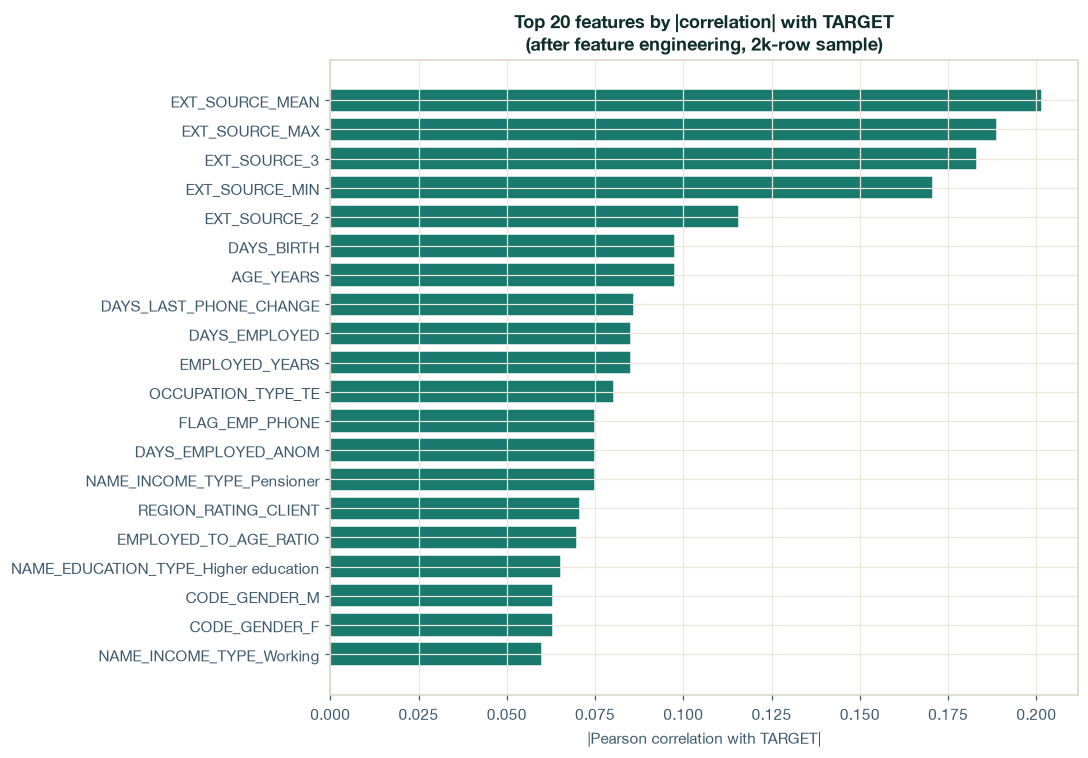

Top 5: EXT_SOURCE_MEAN, EXT_SOURCE_MAX, EXT_SOURCE_3, EXT_SOURCE_MIN, EXT_SOURCE_2


In [18]:
# Top 20 features by |correlation with TARGET| (on sample)
target_col = params["target_column"]
num_cols   = train_f.select_dtypes(include="number").columns.drop(target_col)
corrs = (
    train_f[num_cols.tolist() + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(corrs.index[::-1], corrs.values[::-1], color=TEAL, edgecolor="white")
ax.set_xlabel("|Pearson correlation with TARGET|")
ax.set_title("Top 20 features by |correlation| with TARGET\n(after feature engineering, 2k-row sample)", fontsize=12)
plt.tight_layout()
plt.savefig(REPORT_PATH / "top_features_correlation.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Top 5: {', '.join(corrs.index[:5])}")

<a id="6-layer04"></a>
## 6. 04_feature - Output of `create_features`

After `create_features` runs, the Kedro catalog saves three CSVs to `data/04_feature/`. All three have exactly the same column schema.

| File | Rows | Has TARGET? |
|---|---|---|
| `application_train_features.csv` | 246,008 | Yes |
| `application_validation_features.csv` | 61,503 | Yes |
| `application_test_features.csv` | 48,744 | No |

This is an intermediate checkpoint: all engineered features are saved here before RFE reduces them to the final 50. Storing this layer means `select_features` can be re-run with a different `n_features_to_select` without repeating the (much cheaper) feature engineering step.

<a id="7-feature-selection"></a>
## 7. Feature Selection - RFE with RandomForest

### Tool: `sklearn.feature_selection.RFE`

RFE (Recursive Feature Elimination) works as follows:

1. Fit a `RandomForestClassifier` on all features
2. Rank features by their importance (mean decrease in impurity)
3. Remove the `step` least important features
4. Repeat until exactly `n_features_to_select` features remain

**Why RandomForest as the base estimator?**  
RandomForest provides robust feature importance estimates that are not biased by feature scale or multicollinearity. It naturally handles the mixed numeric + binary + OHE-encoded feature space we have after `create_features`.

**Why RFE over simpler methods?**  
- Simple correlation threshold: ignores interactions between features
- L1 regularisation (Lasso): assumes linear relationships
- Variance threshold: only removes constant features
- RFE: evaluates each feature in context of all others - better for the non-linear nature of credit risk

### Parameter decisions

| Parameter | Value | Rationale |
|---|---|---|
| `n_features_to_select` | 50 | From ~93 features after engineering, keeping 50 (~54%) removes the weakest predictors while retaining most of the signal |
| `rfe_step` | 5 | Removes 5 features per iteration → ~9 RandomForest fits to go from 93 to 50. On 246k rows this is ~5-10 minutes. Increase `step` to reduce runtime |
| `n_estimators` | 100 | Standard RF size; enough to get stable importance estimates |
| `max_depth` | 5 | Shallow trees prevent memorisation during the importance estimation phase |
| `n_jobs` | -1 | Use all CPU cores — critical for 246k rows |

`rfe.fit(X_train, y_train)` uses only training data. Val and test receive the same set of columns via `X[best_columns]` — no importance scores are ever computed using their labels.

### Robustness guard

If `n_features_to_select` exceeds the number of features available after `create_features` (e.g. in a test environment with a small synthetic dataset, or if upstream cleaning drops more columns than expected), `select_features` automatically clamps the value to `n_available` and emits a warning rather than raising an uninformative sklearn error. This is tested in `tests/pipelines/data_feat_engineering/test_nodes.py::TestSelectFeaturesClamp`.

In [7]:
from home_credit_mlops.pipelines.data_feat_engineering.nodes import select_features

# Use faster params for the notebook demo - Kedro uses the full params
demo_params = {**params, "n_features_to_select": 15, "rfe_step": 3,
               "rfe_estimator_params": {"n_estimators": 30, "max_depth": 4,
                                        "random_state": 42, "n_jobs": -1}}

X_train, y_train, X_val, y_val, X_test, best_cols = select_features(
    train_f, val_f, test_f, demo_params
)

print(f"Features before selection : {train_f.shape[1] - 2}  (excl. TARGET + SK_ID_CURR)")
print(f"Features after RFE (demo) : {len(best_cols)}  (production uses {params['n_features_to_select']})")
print()
print(f"X_train : {X_train.shape}  - no TARGET, no SK_ID_CURR")
print(f"y_train : {y_train.shape}  - only TARGET column")
print(f"X_val   : {X_val.shape}   - same columns as X_train")
print(f"y_val   : {y_val.shape}   - only TARGET column")
print(f"X_test  : {X_test.shape}  - same columns, no labels")
print()
print(f"Selected features (demo n=15):")
for i, c in enumerate(sorted(best_cols), 1):
    print(f"  {i:2d}. {c}")

Features before selection : 94  (excl. TARGET + SK_ID_CURR)
Features after RFE (demo) : 15  (production uses 50)

X_train : (2000, 16)  - no TARGET, no SK_ID_CURR
y_train : (2000, 1)  - only TARGET column
X_val   : (500, 16)   - same columns as X_train
y_val   : (500, 1)   - only TARGET column
X_test  : (400, 16)  - same columns, no labels

Selected features (demo n=15):
   1. AMT_REQ_CREDIT_BUREAU_YEAR
   2. CREDIT_ANNUITY_RATIO
   3. DAYS_BIRTH
   4. DAYS_EMPLOYED
   5. DAYS_ID_PUBLISH
   6. DAYS_REGISTRATION
   7. EXT_SOURCE_2
   8. EXT_SOURCE_3
   9. EXT_SOURCE_MAX
  10. EXT_SOURCE_MEAN
  11. EXT_SOURCE_MIN
  12. INCOME_PER_PERSON
  13. OCCUPATION_TYPE_TE
  14. ORGANIZATION_TYPE_TE
  15. REGISTRATION_YEARS


<a id="8-layer05"></a>
## 8. Layer 05_model_input - Output of `select_features`

After `select_features` runs, the Kedro catalog saves five CSVs to `data/05_model_input/` and one pickle to `data/06_models/`:

| File / Entry | Location | Rows | Columns | Notes |
|---|---|---|---|---|
| `X_train.csv` | `05_model_input/` | 246,008 | 50 | Features only — no TARGET, no SK_ID_CURR |
| `y_train.csv` | `05_model_input/` | 246,008 | 1 | Only the `TARGET` column |
| `X_val.csv` | `05_model_input/` | 61,503 | 50 | Same 50 columns as X_train |
| `y_val.csv` | `05_model_input/` | 61,503 | 1 | Only the `TARGET` column |
| `X_test.csv` | `05_model_input/` | 48,744 | 50 | Same 50 columns — no labels exist |
| `best_cols.pkl` | `06_models/` | — | — | Python list of 50 column names (MLflow artifact) |

The split into X/y happens in `select_features` (not in the model training node) for two reasons:

1. **Downstream simplicity**: the `model_train` node receives `X_train` and `y_train` directly and does not need to know which column is the target.
2. **Kedro constraint**: Kedro nodes output named catalog entries, not structured objects. Each DataFrame must be a separate entry.

`best_cols.pkl` is the contract between the feature engineering pipeline and the serving pipeline. When the model is deployed to serve real-time predictions:
- The serving pipeline receives a new application record
- It must apply `create_features` to get the ~93 engineered columns
- It must then apply `X[best_cols]` to get only the 50 columns the model was trained on

Without `best_cols`, serving would not know which subset of features to send to the model.

<a id="9-hopsworks"></a>
## 9. Hopsworks Feature Store - Infrastructure Decisions

### Why Hopsworks?

It provides:
- **Feature Groups**: versioned tables of features
- **Feature Views**: named queries over Feature Groups used for training and serving
- **Statistics**: automated data profiling (histograms, correlations) per feature group version

### Architecture decision: one Feature Group with a `split` column

All three splits (train, validation, test) are uploaded to a **single Feature Group** with a `split` column rather than three separate feature groups. This decision was made because:

| Option | Pros | Cons |
|---|---|---|
| One group + `split` column | Simple retrieval, single schema, statistics computed across all data | Slightly larger table |
| Three separate groups | Clean separation | 3x schema management, harder to query across splits |

The single-group approach is simpler and sufficient for this project scale.

### The TARGET=-1 convention for test rows

Test rows have no ground-truth label. Rather than leaving `TARGET` null (which would require NULL handling), we set `TARGET = -1` as a sentinel. Any downstream query that trains a model should filter with `WHERE split = 'train'` to avoid including these sentinel rows.

### Feature View

A **Feature View** is a named, versioned query over a Feature Group used as the single access point for training and serving. Creating it at upload time means:
- Future model retraining reads from `home_credit_feature_view` (not raw CSVs)
- If features change (new version), the view is updated - consumers automatically get the new schema
- Hopsworks tracks lineage between Feature View and the model trained on it

### Error handling and partial upload recovery

Each Hopsworks operation is individually wrapped in a try/except:

| Stage | On failure |
|---|---|
| `hopsworks.login()` | Returns `{"status": "error", "reason": "login failed: ..."}` — pipeline continues |
| `get_or_create_feature_group()` | Returns `{"status": "error", "reason": "feature group creation failed: ..."}` |
| `fg.insert()` batch loop | Logs which batch failed (e.g. "batch 21/25"), how many rows were already committed, and returns `{"status": "partial", "batches_uploaded": 20, "rows_uploaded": 200000}` |
| Statistics / Feature View | Non-fatal `warning` — upload is already committed, pipeline continues |

This granularity is important: on a 300k-row dataset uploaded in 10k-row batches, a network timeout on batch 25 would otherwise result in a silent partial upload with no indication of where the upload stopped.

### Graceful degradation

If `HOPSWORKS_API_KEY` is absent from `.env`, `to_feature_store()` returns `{"status": "skipped"}` and the rest of the pipeline continues normally. This means the pipeline can run fully locally (for development, testing, CI) without Hopsworks credentials.

### How to activate

1. Create a `.env` file at the project root:
   ```
   HOPSWORKS_API_KEY=<your_key>
   HOPSWORKS_PROJECT=home_credit_mlops
   ```
2. Run `kedro run --pipeline data_feat_engineering`

The upload metadata is saved to `data/08_reporting/feature_store_metadata.json` and tracked in MLflow as an artifact.

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(ROOT_PATH / ".env")

api_key      = os.getenv("HOPSWORKS_API_KEY", "")
project_name = os.getenv("HOPSWORKS_PROJECT", params["hopsworks_project"])

if api_key:
    print("Hopsworks API key found - Feature Store upload ACTIVE when pipeline runs")
    print()
    print(f"  Project        : {project_name}")
    print(f"  Feature Group  : {params['hopsworks_feature_group_name']} v{params['hopsworks_feature_group_version']}")
    print(f"  Feature View   : {params['hopsworks_feature_view_name']} v{params['hopsworks_feature_view_version']}")
    print()
    print("  What will be uploaded:")
    print(f"    Train rows      : {train.shape[0]:,}  (split='train', TARGET=0/1)")
    print(f"    Validation rows : {val.shape[0]:,}  (split='validation', TARGET=0/1)")
    print(f"    Test rows       : {test.shape[0]:,}  (split='test', TARGET=-1 sentinel)")
    print(f"    Total features  : {params['n_features_to_select']} selected by RFE")
else:
    print("HOPSWORKS_API_KEY not set in .env - upload will be SKIPPED by the pipeline.")
    print()
    print("  The pipeline will still run fully:")
    print("  - create_features -> 04_feature (CSVs)")
    print("  - select_features -> 05_model_input (CSVs) + 06_models/best_cols.pkl")
    print("  - to_feature_store -> returns {'status': 'skipped'} -> 08_reporting/feature_store_metadata.json")
    print()
    print("  To activate: add HOPSWORKS_API_KEY=<your_key> to .env at the project root.")